In [1]:
import sys
import subprocess
import ssl

# Unified robust package installer
def install_packages():
    packages = ["numpy", "pandas", "matplotlib", "scikit-learn", "seaborn", 
                "pgmpy", "torch", "torchvision", "tensorflow", "lime", 
                "opencv-python", "mediapipe", "networkx"]
    print("Ensuring dependencies are installed. This might take a moment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
    print("Dependencies successfully installed!")

install_packages()

# Globally bypass SSL verification for datasets downloading 
# (e.g. MNIST, VGG16 weights) to prevent CERTIFICATE_VERIFY_FAILED
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
print("SSL Verification Disabled for dataset downloads.")


Ensuring dependencies are installed. This might take a moment...
Dependencies successfully installed!
SSL Verification Disabled for dataset downloads.


1.  design and implement a Hidden Markov Model (HMM) for weather prediction using observable daily activities.  

In [2]:
import numpy as np

# States
states = ["Sunny", "Rainy"]

# Observations
observations = ["Walking", "Shopping", "Cleaning"]

# Initial probabilities
start_prob = {
    "Sunny": 0.6,
    "Rainy": 0.4
}

# Transition probabilities
transition_prob = {
    "Sunny": {"Sunny": 0.7, "Rainy": 0.3},
    "Rainy": {"Sunny": 0.4, "Rainy": 0.6}
}

# Emission probabilities
emission_prob = {
    "Sunny": {
        "Walking": 0.6,
        "Shopping": 0.3,
        "Cleaning": 0.1
    },
    "Rainy": {
        "Walking": 0.1,
        "Shopping": 0.4,
        "Cleaning": 0.5
    }
}

# Observation sequence
obs_seq = ["Walking", "Shopping", "Cleaning"]

def viterbi(obs_seq, states, start_prob,
            transition_prob, emission_prob):

    V = [{}]
    path = {}

    # Initialize base cases
    for state in states:
        V[0][state] = (
            start_prob[state] *
            emission_prob[state][obs_seq[0]]
        )
        path[state] = [state]

    # Run Viterbi
    for t in range(1, len(obs_seq)):
        V.append({})
        new_path = {}

        for curr_state in states:

            max_prob, prev_state = max(
                (
                    V[t-1][y0] *
                    transition_prob[y0][curr_state] *
                    emission_prob[curr_state][obs_seq[t]],
                    y0
                )
                for y0 in states
            )

            V[t][curr_state] = max_prob
            new_path[curr_state] = (
                path[prev_state] + [curr_state]
            )

        path = new_path

    # Find final best path
    max_prob, final_state = max(
        (V[-1][state], state)
        for state in states
    )

    return max_prob, path[final_state]

# Run model
probability, best_path = viterbi(
    obs_seq,
    states,
    start_prob,
    transition_prob,
    emission_prob
)

print("Most Probable Weather Sequence:")
print(best_path)

print("\nProbability:")
print(probability)

Most Probable Weather Sequence:
['Sunny', 'Rainy', 'Rainy']

Probability:
0.012960000000000001


2.  design and implement a Bayesian Network for predicting whether a student will pass a final exam based on study habits, class attendance, and internal assessment performance. 

/Users/dhruv/Documents/vvenv/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dhruv/Documents/vvenv/.venv/lib/python3.13/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Model Valid: True


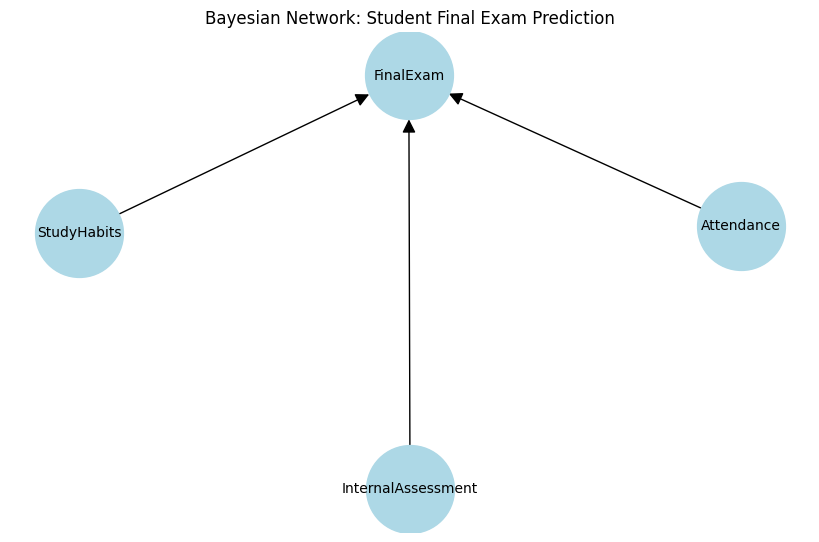


Prediction Results:
+-----------------+------------------+
| FinalExam       |   phi(FinalExam) |
+=================+==================+
| FinalExam(Fail) |           0.0500 |
+-----------------+------------------+
| FinalExam(Pass) |           0.9500 |
+-----------------+------------------+

--- Multiple Predictions ---

Case 1
Input: {'StudyHabits': 'Good', 'Attendance': 'High', 'InternalAssessment': 'Strong'}
+-----------------+------------------+
| FinalExam       |   phi(FinalExam) |
+=================+==================+
| FinalExam(Fail) |           0.0500 |
+-----------------+------------------+
| FinalExam(Pass) |           0.9500 |
+-----------------+------------------+

Case 2
Input: {'StudyHabits': 'Poor', 'Attendance': 'Low', 'InternalAssessment': 'Weak'}
+-----------------+------------------+
| FinalExam       |   phi(FinalExam) |
+=================+==================+
| FinalExam(Fail) |           0.9500 |
+-----------------+------------------+
| FinalExam(Pass) |      

In [3]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import matplotlib.pyplot as plt
import networkx as nx

# ---------------------------------
# Step 1: Define Bayesian Structure
# ---------------------------------

model = DiscreteBayesianNetwork([
    ('StudyHabits', 'FinalExam'),
    ('Attendance', 'FinalExam'),
    ('InternalAssessment', 'FinalExam')
])

# ---------------------------------
# Step 2: Define Conditional Probabilities
# ---------------------------------

# Study Habits
cpd_study = TabularCPD(
    variable='StudyHabits',
    variable_card=2,
    values=[[0.4], [0.6]],
    state_names={
        'StudyHabits': ['Poor', 'Good']
    }
)

# Attendance
cpd_attendance = TabularCPD(
    variable='Attendance',
    variable_card=2,
    values=[[0.3], [0.7]],
    state_names={
        'Attendance': ['Low', 'High']
    }
)

# Internal Assessment
cpd_internal = TabularCPD(
    variable='InternalAssessment',
    variable_card=2,
    values=[[0.35], [0.65]],
    state_names={
        'InternalAssessment': ['Weak', 'Strong']
    }
)

# Final Exam CPD
cpd_final = TabularCPD(
    variable='FinalExam',
    variable_card=2,

    values=[
        # FAIL probabilities
        [
            0.95, 0.80, 0.75, 0.50,
            0.70, 0.45, 0.30, 0.05
        ],

        # PASS probabilities
        [
            0.05, 0.20, 0.25, 0.50,
            0.30, 0.55, 0.70, 0.95
        ]
    ],

    evidence=[
        'StudyHabits',
        'Attendance',
        'InternalAssessment'
    ],

    evidence_card=[2,2,2],

    state_names={
        'FinalExam': ['Fail','Pass'],
        'StudyHabits': ['Poor','Good'],
        'Attendance': ['Low','High'],
        'InternalAssessment': ['Weak','Strong']
    }
)

# ---------------------------------
# Step 3: Add CPDs to Model
# ---------------------------------

model.add_cpds(
    cpd_study,
    cpd_attendance,
    cpd_internal,
    cpd_final
)

# Verify model correctness
print("Model Valid:", model.check_model())

# ---------------------------------
# Step 4: Visualize Network
# ---------------------------------

plt.figure(figsize=(8,5))

G = nx.DiGraph(model.edges())

nx.draw(
    G,
    with_labels=True,
    node_size=4000,
    node_color='lightblue',
    font_size=10,
    arrowsize=20
)

plt.title("Bayesian Network: Student Final Exam Prediction")
plt.show()

# ---------------------------------
# Step 5: Perform Inference
# ---------------------------------

inference = VariableElimination(model)

# Example Prediction

result = inference.query(
    variables=['FinalExam'],
    evidence={
        'StudyHabits': 'Good',
        'Attendance': 'High',
        'InternalAssessment': 'Strong'
    }
)

print("\nPrediction Results:")
print(result)

# ---------------------------------
# Step 6: Multiple Scenarios
# ---------------------------------

test_cases = [

    {
        'StudyHabits':'Good',
        'Attendance':'High',
        'InternalAssessment':'Strong'
    },

    {
        'StudyHabits':'Poor',
        'Attendance':'Low',
        'InternalAssessment':'Weak'
    },

    {
        'StudyHabits':'Good',
        'Attendance':'Low',
        'InternalAssessment':'Strong'
    }
]

print("\n--- Multiple Predictions ---")

for i, case in enumerate(test_cases,1):

    prediction = inference.query(
        variables=['FinalExam'],
        evidence=case
    )

    print(f"\nCase {i}")
    print("Input:", case)
    print(prediction)

3. design and implement a Gaussian Mixture Model (GMM) for outcome prediction on a real-world dataset. 



Model Accuracy:
66.67%

Confusion Matrix:
[[50  0  0]
 [ 2  0 48]
 [ 0  0 50]]

Classification Report:
              precision    recall  f1-score   support

      setosa       0.96      1.00      0.98        50
  versicolor       0.00      0.00      0.00        50
   virginica       0.51      1.00      0.68        50

    accuracy                           0.67       150
   macro avg       0.49      0.67      0.55       150
weighted avg       0.49      0.67      0.55       150



/Users/dhruv/Documents/vvenv/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dhruv/Documents/vvenv/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dhruv/Documents/vvenv/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

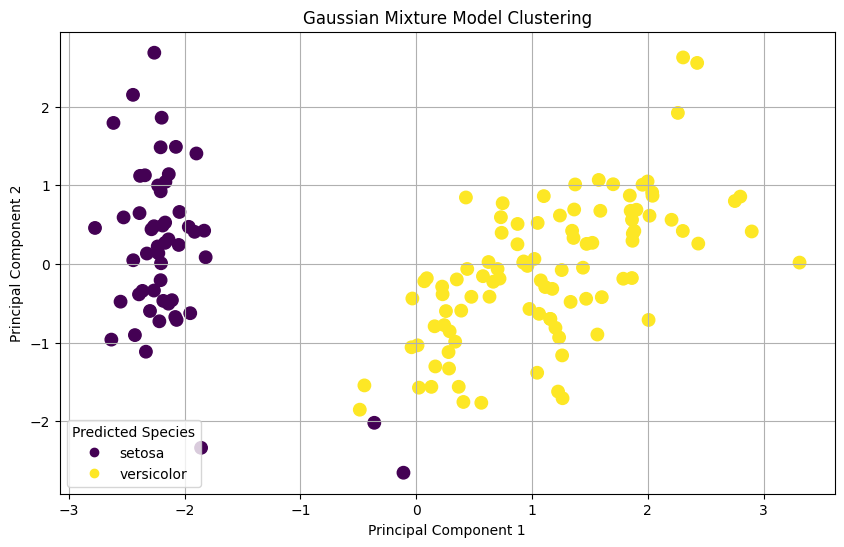


New Sample Predictions:
Sample 1: setosa
Sample 2: virginica
Sample 3: virginica


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ----------------------------------------
# Step 1: Load Real-World Dataset
# ----------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# ----------------------------------------
# Step 2: Normalize Data
# ----------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------
# Step 3: Train Gaussian Mixture Model
# ----------------------------------------

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

# Predict clusters
clusters = gmm.predict(X_scaled)

# ----------------------------------------
# Step 4: Map Clusters to Actual Labels
# ----------------------------------------

# Since clustering labels are arbitrary,
# we map them manually to closest classes.

mapping = {}

for i in range(3):

    mask = (clusters == i)

    true_labels = y[mask]

    mapped_label = np.bincount(true_labels).argmax()

    mapping[i] = mapped_label

# Convert cluster labels
predicted_labels = np.vectorize(mapping.get)(clusters)

# ----------------------------------------
# Step 5: Evaluate Model
# ----------------------------------------

accuracy = accuracy_score(y, predicted_labels)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y, predicted_labels))

print("\nClassification Report:")
print(classification_report(
    y,
    predicted_labels,
    target_names=target_names
))

# ----------------------------------------
# Step 6: Reduce Dimensions for Visualization
# ----------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# ----------------------------------------
# Step 7: Plot Clusters
# ----------------------------------------

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=predicted_labels,
    s=80
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Gaussian Mixture Model Clustering")

# Legend
handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    target_names,
    title="Predicted Species"
)

plt.grid(True)

plt.show()

# ----------------------------------------
# Step 8: Predict New Samples
# ----------------------------------------

new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.5, 3.0, 5.2, 2.0],
    [5.9, 3.0, 4.2, 1.5]
])

# Normalize
new_samples_scaled = scaler.transform(new_samples)

# Predict clusters
new_clusters = gmm.predict(new_samples_scaled)

# Convert to class labels
new_predictions = np.vectorize(mapping.get)(new_clusters)

print("\nNew Sample Predictions:")

for i, pred in enumerate(new_predictions):

    print(f"Sample {i+1}: {target_names[pred]}")

4. build and train a Generative Multi-Layer Network Model that maps a low-dimensional latent space to a target data distribution. This experiment will demonstrate how a feed-forward neural network (a multilayer perceptron) can be used as a generative model for outcome generation.

Epoch [0/3000] Loss: 1.0712
Epoch [300/3000] Loss: 1.0484
Epoch [600/3000] Loss: 1.0443
Epoch [900/3000] Loss: 1.0076
Epoch [1200/3000] Loss: 1.0509
Epoch [1500/3000] Loss: 0.9415
Epoch [1800/3000] Loss: 0.9780
Epoch [2100/3000] Loss: 0.9316
Epoch [2400/3000] Loss: 1.0439
Epoch [2700/3000] Loss: 0.9819


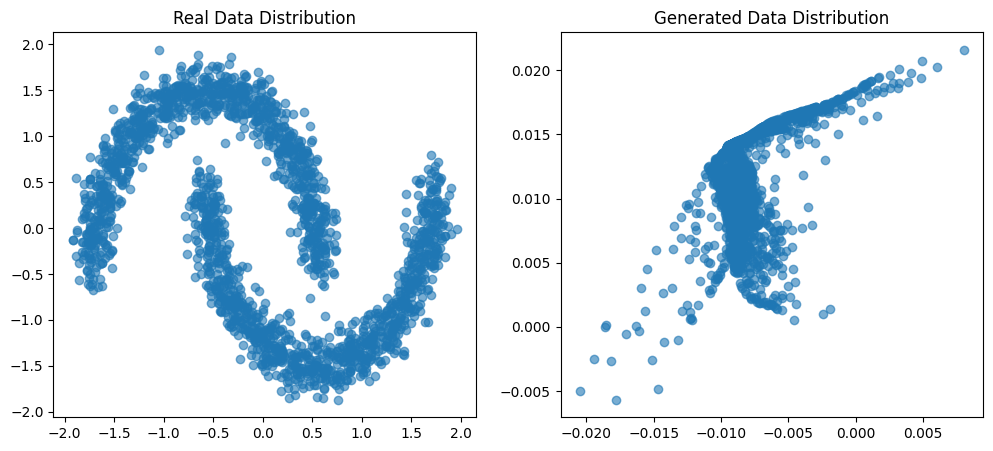

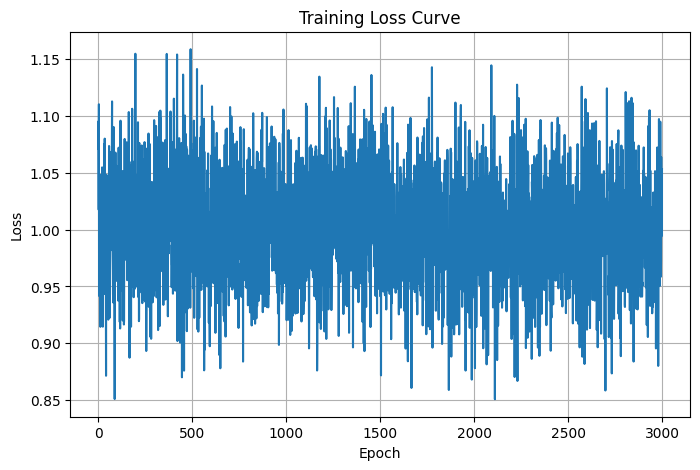

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# Step 1: Generate Real Dataset
# --------------------------------------------

X, y = make_moons(
    n_samples=2000,
    noise=0.08,
    random_state=42
)

# Normalize dataset
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train = torch.tensor(X, dtype=torch.float32)

# --------------------------------------------
# Step 2: Define Latent Space
# --------------------------------------------

LATENT_DIM = 2

# --------------------------------------------
# Step 3: Build Generative Multi-Layer Network
# --------------------------------------------

class Generator(nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(LATENT_DIM, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 2)
        )

    def forward(self, z):
        return self.network(z)

# Initialize model
generator = Generator()

# --------------------------------------------
# Step 4: Loss Function and Optimizer
# --------------------------------------------

criterion = nn.MSELoss()

optimizer = optim.Adam(
    generator.parameters(),
    lr=0.001
)

# --------------------------------------------
# Step 5: Training Loop
# --------------------------------------------

EPOCHS = 3000
BATCH_SIZE = 128

losses = []

for epoch in range(EPOCHS):

    # Sample random latent vectors
    z = torch.randn(BATCH_SIZE, LATENT_DIM)

    # Generate fake samples
    generated_samples = generator(z)

    # Randomly choose real samples
    idx = np.random.randint(
        0,
        len(X_train),
        BATCH_SIZE
    )

    real_samples = X_train[idx]

    # Compute loss
    loss = criterion(
        generated_samples,
        real_samples
    )

    # Backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    # Print progress
    if epoch % 300 == 0:

        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"Loss: {loss.item():.4f}"
        )

# --------------------------------------------
# Step 6: Generate New Samples
# --------------------------------------------

with torch.no_grad():

    z = torch.randn(2000, LATENT_DIM)

    generated_data = generator(z).numpy()

# --------------------------------------------
# Step 7: Visualization
# --------------------------------------------

plt.figure(figsize=(12,5))

# Real Data
plt.subplot(1,2,1)

plt.scatter(
    X[:,0],
    X[:,1],
    alpha=0.6
)

plt.title("Real Data Distribution")

# Generated Data
plt.subplot(1,2,2)

plt.scatter(
    generated_data[:,0],
    generated_data[:,1],
    alpha=0.6
)

plt.title("Generated Data Distribution")

plt.show()

# --------------------------------------------
# Step 8: Plot Training Loss
# --------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.grid(True)

plt.show()

5. build and train a Deep Convolution Generative Adversarial Network (DCGAN) for generating realistic images from a given image dataset

Using Device: mps
Starting Training...
Epoch [1/1] Batch 0/469 Loss D: 1.2921, Loss G: 2.5630
Epoch [1/1] Batch 100/469 Loss D: 0.0042, Loss G: 8.2821
Epoch [1/1] Batch 200/469 Loss D: 0.4125, Loss G: 5.4693
Epoch [1/1] Batch 300/469 Loss D: 0.6646, Loss G: 2.1128
Epoch [1/1] Batch 400/469 Loss D: 0.6915, Loss G: 1.8852
Generating Images...


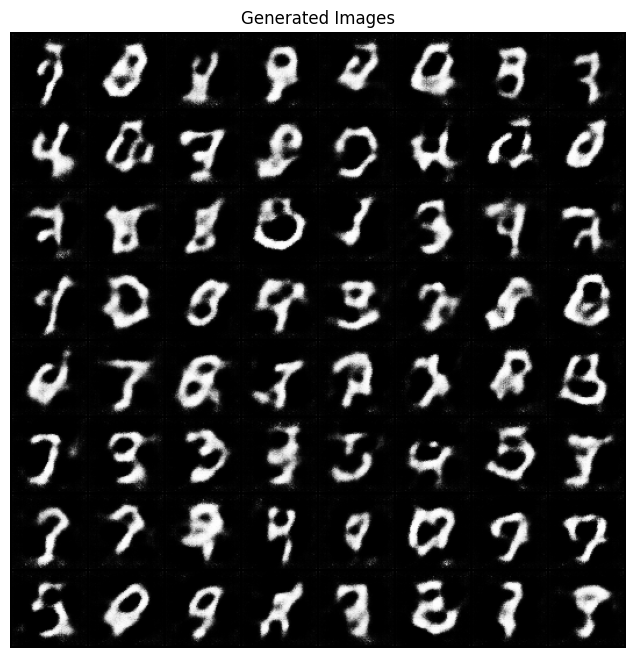

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision.utils import make_grid
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import ssl

# -------------------------------------------------
# Step 1: Device Configuration
# -------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Using Device:", device)

# -------------------------------------------------
# Step 2: Hyperparameters
# -------------------------------------------------

BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS = 1
LATENT_DIM = 100

EPOCHS = 1
LEARNING_RATE = 0.0002

# -------------------------------------------------
# Step 3: Data Preprocessing
# -------------------------------------------------

transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5],
        [0.5]
    )
])

# MNIST Dataset
# Disable SSL verification for MNIST download

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -------------------------------------------------
# Step 4: Generator Network
# -------------------------------------------------

class Generator(nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(
                LATENT_DIM, 512,
                4, 1, 0,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                512, 256,
                4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256, 128,
                4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128, 64,
                4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64, CHANNELS,
                4, 2, 1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# -------------------------------------------------
# Step 5: Discriminator Network
# -------------------------------------------------

class Discriminator(nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                CHANNELS, 64,
                4, 2, 1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64, 128,
                4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128, 256,
                4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                256, 512,
                4, 2, 1,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                512, 1,
                4, 1, 0,
                bias=False
            ),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# -------------------------------------------------
# Step 6: Initialize Models
# -------------------------------------------------

generator = Generator().to(device)
discriminator = Discriminator().to(device)

# -------------------------------------------------
# Step 7: Loss and Optimizers
# -------------------------------------------------

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

# -------------------------------------------------
# Step 8: Training Loop
# -------------------------------------------------

print("Starting Training...")

for epoch in range(EPOCHS):

    for batch_idx, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        # Real and Fake labels
        real_labels = torch.ones(
            batch_size, 1, 1, 1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size, 1, 1, 1
        ).to(device)

        # ---------------------------------
        # Train Discriminator
        # ---------------------------------

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1
        ).to(device)

        fake_images = generator(noise)

        discriminator.zero_grad()

        # Real Loss
        real_output = discriminator(real_images)

        loss_real = criterion(
            real_output,
            real_labels
        )

        # Fake Loss
        fake_output = discriminator(
            fake_images.detach()
        )

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total Discriminator Loss
        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()

        # ---------------------------------
        # Train Generator
        # ---------------------------------

        generator.zero_grad()

        fake_output = discriminator(fake_images)

        loss_G = criterion(
            fake_output,
            real_labels
        )

        loss_G.backward()

        optimizer_G.step()

        # ---------------------------------
        # Print Progress
        # ---------------------------------

        if batch_idx % 100 == 0:

            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Batch {batch_idx}/{len(dataloader)} "
                f"Loss D: {loss_D.item():.4f}, "
                f"Loss G: {loss_G.item():.4f}"
            )

# -------------------------------------------------
# Step 9: Generate Images
# -------------------------------------------------

print("Generating Images...")

with torch.no_grad():

    noise = torch.randn(
        64,
        LATENT_DIM,
        1,
        1
    ).to(device)

    fake_images = generator(noise).cpu()

# Denormalize images
fake_images = fake_images * 0.5 + 0.5

grid = make_grid(
    fake_images,
    nrow=8
)

plt.figure(figsize=(8,8))

plt.imshow(
    np.transpose(grid, (1,2,0))
)

plt.axis("off")

plt.title("Generated Images")

plt.show()

In [8]:
import os
import cv2
import numpy as np

# Automatically generate a minimal dummy dataset for VGG16 (Experiment 6) and LIME (Experiment 7)
# This prevents FileNotFoundError if the folders don't exist in the cloned repository.

def create_dummy_dataset():
    dirs = ['dataset/train/classA', 'dataset/train/classB',
            'dataset/validation/classA', 'dataset/validation/classB',
            'dataset/test/classA', 'dataset/test/classB']
            
    for d in dirs:
        os.makedirs(d, exist_ok=True)
        # Create 2 dummy images per class per split
        for i in range(2):
            img_path = os.path.join(d, f"dummy_{i}.jpg")
            if not os.path.exists(img_path):
                # Random colored image
                img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
                cv2.imwrite(img_path, img)
                
    # Create sample.jpg for Step 11
    if not os.path.exists('sample.jpg'):
        img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
        cv2.imwrite('sample.jpg', img)

create_dummy_dataset()
print("Verified dataset directories and sample images for Experiment 6.")


Verified dataset directories and sample images for Experiment 6.


6. explore the working of a pre-trained model (VGG16) for outcome generation and to use transfer learning to classify images from a custom dataset.

Found 4 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.5910 - val_accuracy: 0.5000 - val_loss: 0.7209
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step - accuracy: 0.5000 - loss: 0.7355



Test Accuracy: 50.00%

Model Saved Successfully!


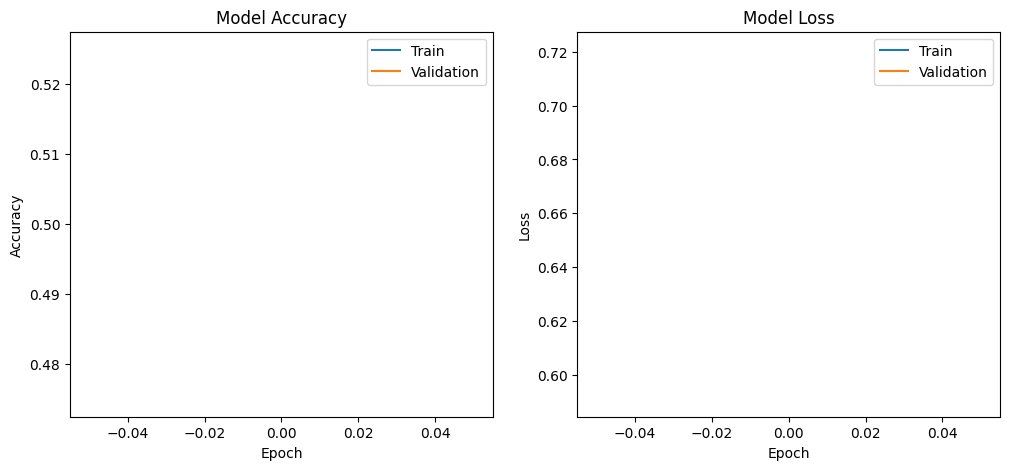

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step

Predicted Class:
classA


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Dropout
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# Step 1: Dataset Paths
# ---------------------------------------------------

TRAIN_DIR = "dataset/train"
VAL_DIR = "dataset/validation"
TEST_DIR = "dataset/test"

# ---------------------------------------------------
# Step 2: Parameters
# ---------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 1

# ---------------------------------------------------
# Step 3: Data Preprocessing
# ---------------------------------------------------

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(

    VAL_DIR,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

# ---------------------------------------------------
# Step 4: Load Pre-trained VGG16
# ---------------------------------------------------

base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# ---------------------------------------------------
# Step 5: Build Transfer Learning Model
# ---------------------------------------------------

model = Sequential([

    base_model,

    Flatten(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(
        train_data.num_classes,
        activation='softmax'
    )
])

# ---------------------------------------------------
# Step 6: Compile Model
# ---------------------------------------------------

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# ---------------------------------------------------
# Step 7: Train Model
# ---------------------------------------------------

history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=EPOCHS
)

# ---------------------------------------------------
# Step 8: Evaluate Model
# ---------------------------------------------------

loss, accuracy = model.evaluate(test_data)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# ---------------------------------------------------
# Step 9: Save Model
# ---------------------------------------------------

model.save("vgg16_transfer_learning_model.h5")

print("\nModel Saved Successfully!")

# ---------------------------------------------------
# Step 10: Plot Accuracy and Loss
# ---------------------------------------------------

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

# ---------------------------------------------------
# Step 11: Predict on New Image
# ---------------------------------------------------

from tensorflow.keras.preprocessing import image

img_path = "sample.jpg"

img = image.load_img(

    img_path,

    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_labels = list(
    train_data.class_indices.keys()
)

print("\nPredicted Class:")

print(class_labels[predicted_class])

7. implement and analyze the working of the Local Interpretable Model-Agnostic Explanations (LIME) framework to interpret model predictions in a supervised classification problem.


Model Accuracy:
96.49%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
[[40  3]
 [ 1 70]]

LIME Explanation:

worst area > 1031.50: -0.1580
worst concave points > 0.16: -0.1280
worst perimeter > 124.65: -0.1026
worst radius > 18.41: -0.0796
worst texture > 29.69: -0.0636
worst concavity > 0.39: -0.0609
mean concave points > 0.07: -0.0561
area error > 43.73: -0.0540
mean concavity > 0.13: -0.0467
mean texture > 21.59: -0.0360


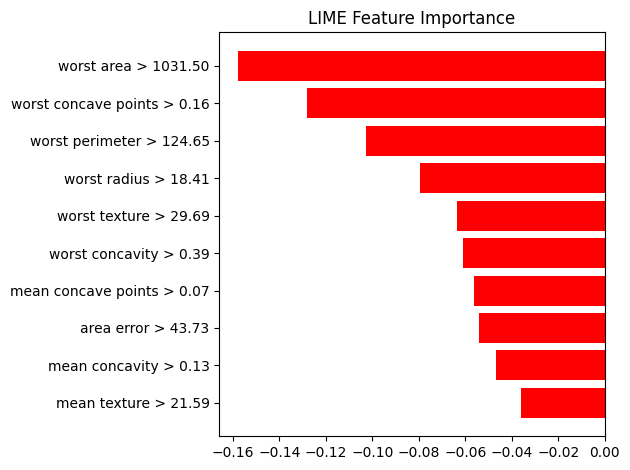


LIME explanation saved as HTML file!

Actual Class:
malignant

Predicted Class:
malignant

Prediction Probabilities:
malignant: 1.0000
benign: 0.0000


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from lime.lime_tabular import LimeTabularExplainer

# ---------------------------------------------------
# Step 1: Load Dataset
# ---------------------------------------------------

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

# ---------------------------------------------------
# Step 2: Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

# ---------------------------------------------------
# Step 3: Train Classification Model
# ---------------------------------------------------

model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------
# Step 4: Evaluate Model
# ---------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ---------------------------------------------------
# Step 5: Create LIME Explainer
# ---------------------------------------------------

explainer = LimeTabularExplainer(

    training_data=X_train,

    feature_names=feature_names,

    class_names=class_names,

    mode='classification'
)

# ---------------------------------------------------
# Step 6: Select Test Instance
# ---------------------------------------------------

instance_index = 5

instance = X_test[instance_index]

# ---------------------------------------------------
# Step 7: Generate LIME Explanation
# ---------------------------------------------------

explanation = explainer.explain_instance(

    data_row=instance,

    predict_fn=model.predict_proba,

    num_features=10
)

# ---------------------------------------------------
# Step 8: Print Explanation
# ---------------------------------------------------

print("\nLIME Explanation:\n")

for feature, weight in explanation.as_list():

    print(f"{feature}: {weight:.4f}")

# ---------------------------------------------------
# Step 9: Visualize Explanation
# ---------------------------------------------------

fig = explanation.as_pyplot_figure()

plt.title("LIME Feature Importance")

plt.tight_layout()

plt.show()

# ---------------------------------------------------
# Step 10: Save HTML Explanation
# ---------------------------------------------------

explanation.save_to_file("lime_explanation.html")

print("\nLIME explanation saved as HTML file!")

# ---------------------------------------------------
# Step 11: Compare Prediction
# ---------------------------------------------------

predicted_class = model.predict([instance])[0]

prediction_prob = model.predict_proba([instance])[0]

print("\nActual Class:")
print(class_names[y_test[instance_index]])

print("\nPredicted Class:")
print(class_names[predicted_class])

print("\nPrediction Probabilities:")

for i, prob in enumerate(prediction_prob):

    print(f"{class_names[i]}: {prob:.4f}")

8. To conduct a case study on emerging artificial intelligence technologies such as the Metaverse and Augmented Reality (AR), exploring their AI foundations, current applications, and future trends.


In [12]:
import cv2
import mediapipe as mp
import numpy as np
import urllib.request
import os

# ---------------------------------------------------
# Step 1: Initialize MediaPipe Hand Tracking (Cross-Platform)
# ---------------------------------------------------

# Download the Hand Landmarker model file if not present
model_path = 'hand_landmarker.task'
if not os.path.exists(model_path):
    print("Downloading MediaPipe Hand Landmarker Model...")
    urllib.request.urlretrieve('https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task', model_path)
    print("Download complete.")

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.7,
    min_hand_presence_confidence=0.7,
    min_tracking_confidence=0.7
)
detector = vision.HandLandmarker.create_from_options(options)

# ---------------------------------------------------
# Step 2: Open Webcam
# ---------------------------------------------------

cap = cv2.VideoCapture(0)

# ---------------------------------------------------
# Step 3: AR Overlay Function
# ---------------------------------------------------

def draw_virtual_object(frame, x, y):
    # Draw virtual AR cube
    cv2.rectangle(
        frame,
        (x - 50, y - 50),
        (x + 50, y + 50),
        (255, 0, 0),
        3
    )

    cv2.putText(
        frame,
        "AR Object",
        (x - 40, y - 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

# ---------------------------------------------------
# Step 4: Real-Time Processing
# ---------------------------------------------------

print("Starting Webcam AR Demo... (Will automatically close after 100 frames to prevent hanging)")

frame_count = 0
MAX_FRAMES = 200000

while cap.isOpened() and frame_count < MAX_FRAMES:
    success, frame = cap.read()
    if not success:
        print("Ignoring empty camera frame.")
        break
        
    frame_count += 1

    # Flip frame for mirror effect
    frame = cv2.flip(frame, 1)
    h, w, c = frame.shape

    # Convert BGR to RGB for MediaPipe
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

    # Hand Detection using Tasks API
    detection_result = detector.detect(mp_image)

    # ------------------------------------------------
    # Step 5: Hand Landmark Detection
    # ------------------------------------------------

    if detection_result.hand_landmarks:
        for hand_landmarks in detection_result.hand_landmarks:
            # Draw standard landmarks (simple manual drawing for cross-platform compatibility)
            for landmark in hand_landmarks:
                lx, ly = int(landmark.x * w), int(landmark.y * h)
                cv2.circle(frame, (lx, ly), 3, (255, 0, 0), -1)

            # Get index fingertip position (Index 8 in MediaPipe hand landmarks)
            index_tip = hand_landmarks[8]
            cx = int(index_tip.x * w)
            cy = int(index_tip.y * h)

            # ------------------------------------------------
            # Step 6: Draw AI-Based AR Object
            # ------------------------------------------------

            draw_virtual_object(frame, cx, cy)

            # Draw tracking point
            cv2.circle(
                frame,
                (cx, cy),
                10,
                (0, 0, 255),
                -1
            )

    # ------------------------------------------------
    # Step 7: Display Output
    # ------------------------------------------------

    cv2.putText(
        frame,
        "AI + Augmented Reality Demo",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )
    cv2.putText(
        frame,
        f"Frame: {frame_count}/{MAX_FRAMES} (Press ESC to exit)",
        (20, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 255),
        2
    )

    cv2.imshow("Metaverse & AR AI System", frame)

    # Exit on ESC
    if cv2.waitKey(1) == 27:
        break

# ---------------------------------------------------
# Step 8: Cleanup
# ---------------------------------------------------

cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1) # macOS fix for fully destroying window
print("AR Demo finished successfully.")


I0000 00:00:1779204272.618586  203529 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1779204272.621536  203532 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779204272.625121  203532 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Starting Webcam AR Demo... (Will automatically close after 100 frames to prevent hanging)


W0000 00:00:1779204274.025978  203533 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


KeyboardInterrupt: 